# HOMEWORK 12

In this homework you are going to inspect the GTSDB (German Traffic Sign Detection Benchmark) dataset. The dataset contains images of various classes of traffic signs used in Germany (and the whole EU). The objective of this homework is to go through the steps described below and to implement the necessary code.

At the end, as usual, there will be a couple of questions for you to answer. In addition, the last section of this homework is optional and, if you chose to do it, you'll earn extra point :-)

In [5]:
import os
import cv2
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

### Step 0

Go to the GTSRB dataset official site ([link](https://benchmark.ini.rub.de/gtsrb_dataset.html)) to learn more about the dataset.

### Step 1

Download the dataset ([link](https://www.kaggle.com/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign)) and unzip it.

### Step 2

For this homework, you will be working with the training set. Check out the `Train.csv`, open it and see what it contains. Load the dataset and plot random samples.

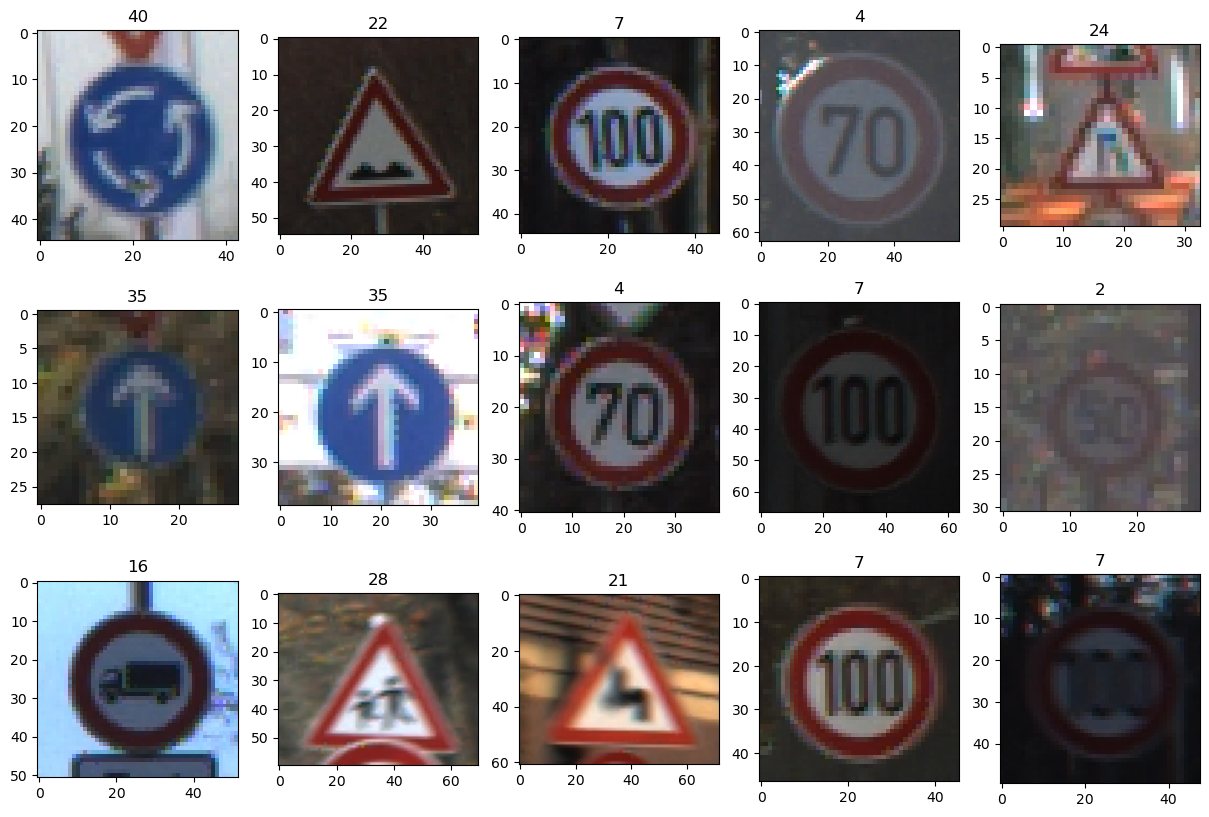

In [2]:
# Load the training labels
root = 'D:/dataset' # Path to the dataset location, e.g., '/data/janko/dataset/GTSRB'
data = pd.read_csv(os.path.join(root, 'Train.csv'))

# Number of training samples (amount of samples in data)
num_samples = data.shape[0]

# Show random data samples
for ii in range(15):
    # Get random index
    idx = np.random.randint(0, num_samples)
    # Load image
    img = cv2.imread(os.path.join(root, data.iloc[idx]['Path']))
    # Convert image to RGB
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    # Show image
    plt.subplot(3,5,ii+1), plt.imshow(img), plt.title(data.iloc[idx]['ClassId'])

### Step 3

Inspect the dataset by computing and plotting the per-class histogram.

In [3]:
# Extract class identifiers
# Hint: Check the csv 
ids = data["ClassId"].values


Compute the per class histogram. You can use any approach you want (e.g. `numpy`). It's also worth looking at the `Counter` function from the `collections` module ([link](https://docs.python.org/3/library/collections.html#collections.Counter)) ;-)

(Text(0.5, 0, 'Traffic Sign ID'), Text(0, 0.5, 'Counts'))

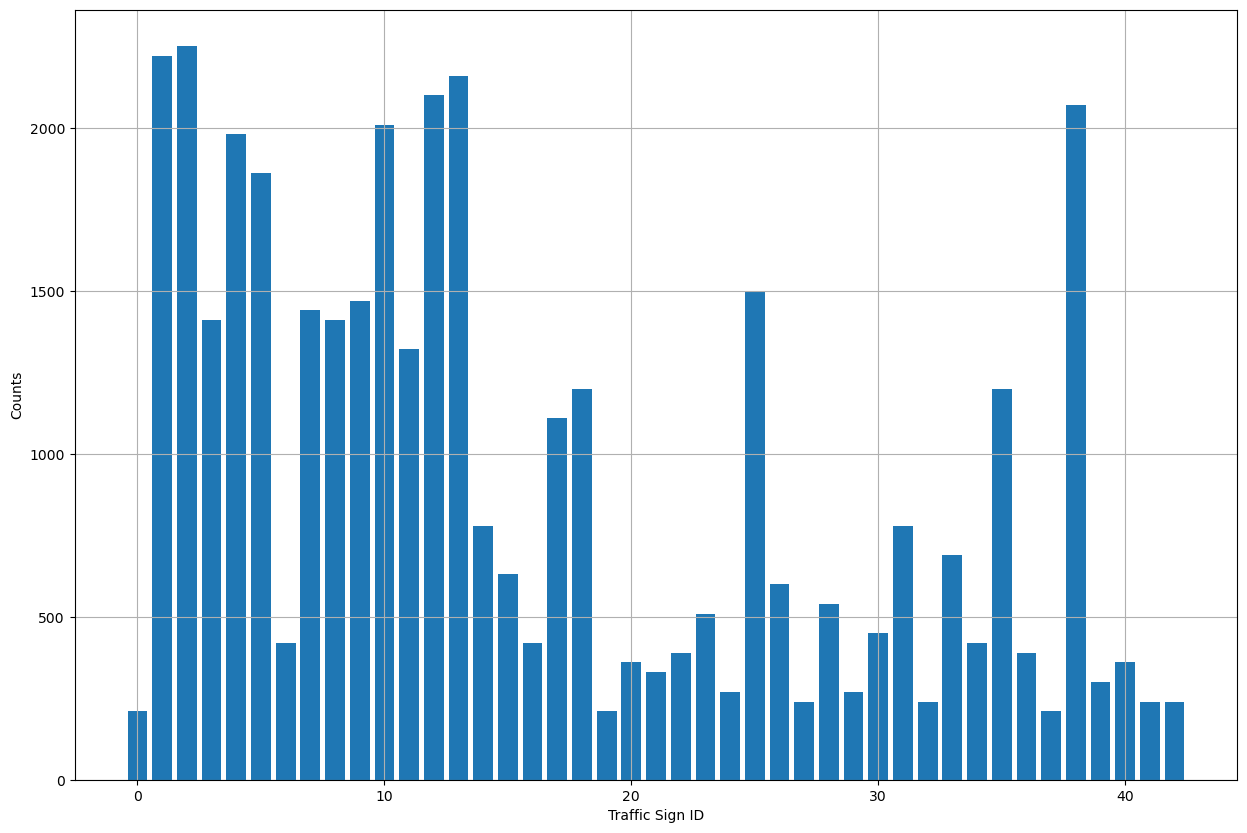

In [4]:
from collections import Counter
hist = Counter(ids)

plt.bar(hist.keys(), hist.values()), plt.grid(True)
plt.xlabel('Traffic Sign ID'), plt.ylabel('Counts')

### Questions

Please answer the following questions:
* Do you consider the dataset to be balanced? If so, why? If not, why?
  Definitely, the dataset is not balanced since the amount of samples for different classes could be different more than in 10 times.
  
* Are there any classes that are (significantly) over-represented or under-represeneted?

I would say that all classes which have less than 500 samples are under-represented. The classes which have more than 1500 samples are over-represented. This imbalance can affect the neural network’s performance, making it biased towards predicting more frequent classes.


### Optional

Perform a further analysis on the dataset and draw some conclusion from it.

Hint 1: Unlike MNIST or CIFAR10, this dataset contains images with various spatial resolutions. Is there anything we can tell about the resolution distribution?
Hint 2: What about the brightness distribution? Are there classes there are significantly more bright than others?

I did some experiment further.
1. Distribution of spatial resolution through all images of all classes. It looks like images of lower resolution (smaller width and height) are more represented in the dataset then images with higher resolution.
2. Distribution of average resolution for each class. It looks like more or less balanced.
3. Distribution of brightness for all images of all classes. Looks like we darker images are more represented in the dataset 
4. Distribution of average brightness for each class. It looks like more or less balanced.

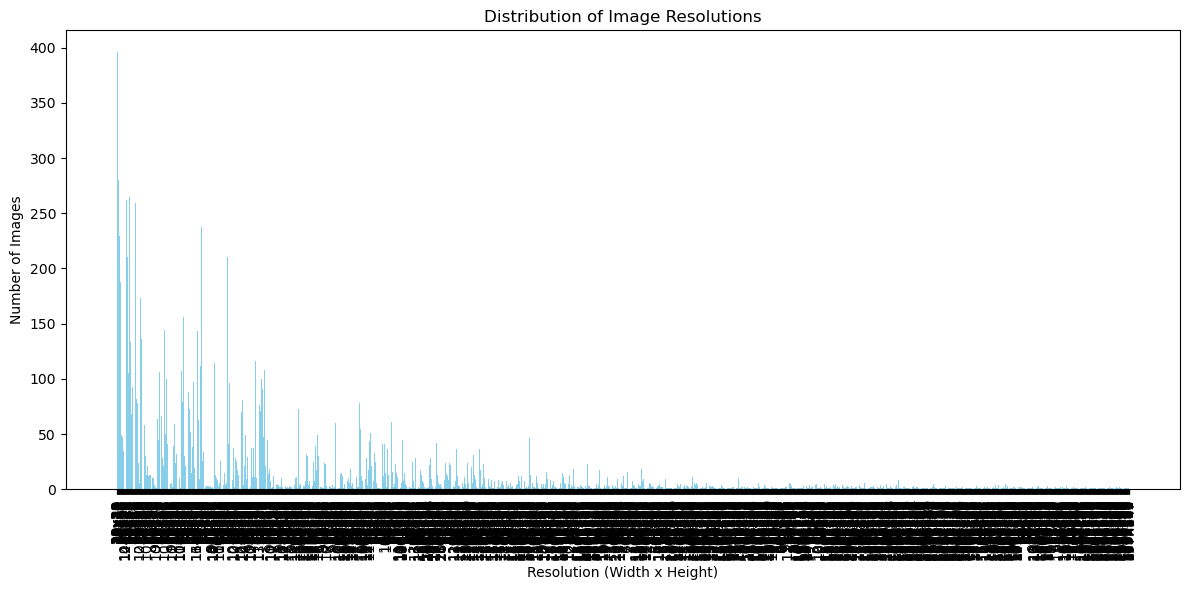

(29, 30)
(30, 30)
(31, 31)
(30, 32)
(33, 34)
(34, 35)
(36, 36)
(35, 36)
(37, 38)
(40, 39)
(41, 42)


In [16]:
from PIL import Image

# Set the root directory of your dataset
dataset_dir = 'D:/dataset/train'

# Get a list of resolution for each image
resolutions = []

for root, dirs, files in os.walk(dataset_dir):
    for filename in files:
        if filename.endswith(('.png', '.jpg', '.jpeg')):  
            file_path = os.path.join(root, filename)
            try:
                with Image.open(file_path) as img:
                    resolutions.append(img.size)  # (width, height)
            except Exception as e:
                print(f"Error loading {file_path}: {e}")


# Count occurrences of each resolution
resolution_counts = Counter(resolutions)

# Prepare data for plotting
x = ['{}x{}'.format(*res) for res in resolution_counts.keys()]
y = list(resolution_counts.values())

# Plot the histogram
plt.figure(figsize=(12, 6))
plt.bar(x, y, color='skyblue')
plt.xlabel('Resolution (Width x Height)')
plt.ylabel('Number of Images')
plt.xticks(rotation=90)  # Rotate x labels for better readability
plt.title('Distribution of Image Resolutions')
plt.tight_layout()
plt.show()

i=0
for res in resolution_counts.keys():
    print(res)
    i=i+1
    if i>10:
        break


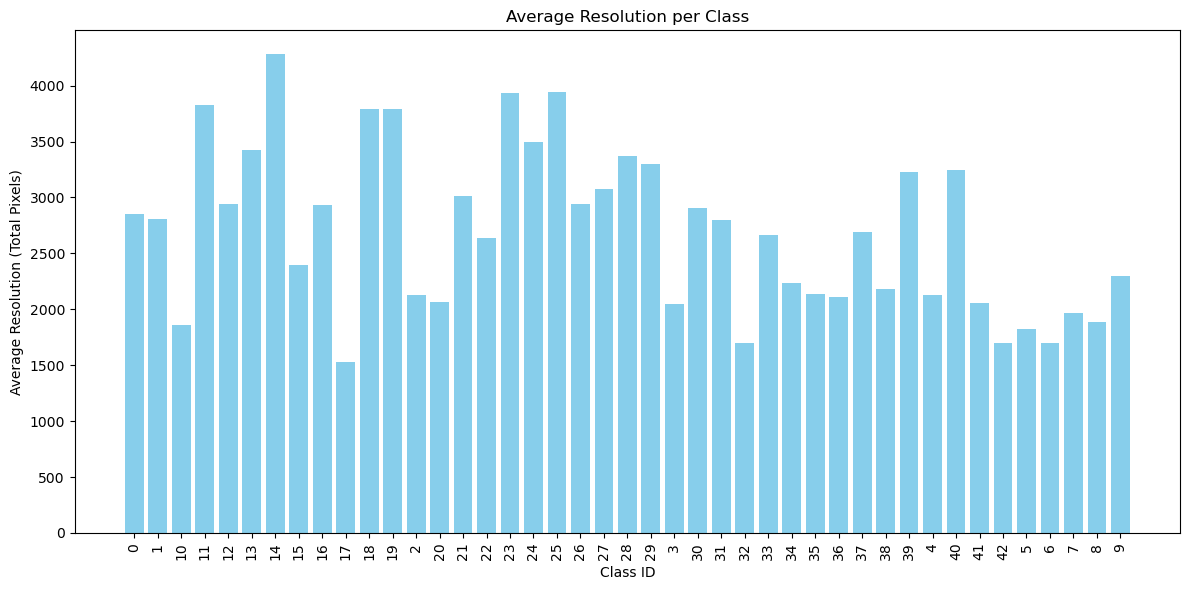

In [17]:
from collections import defaultdict

# Dictionary to store list of resolutions for each class
class_resolutions = defaultdict(list)

# Walk through dataset directory and subfolders
for root, dirs, files in os.walk(dataset_dir):
    class_name = os.path.basename(root)  # Folder name as class ID
    for filename in files:
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            file_path = os.path.join(root, filename)
            try:
                with Image.open(file_path) as img:
                    width, height = img.size
                    class_resolutions[class_name].append((width, height))
            except Exception as e:
                print(f"Error processing {file_path}: {e}")

# Calculate average resolution per class
avg_resolution_per_class = {}
for cls, res_list in class_resolutions.items():
    if res_list:
        avg_width = np.mean([res[0] for res in res_list])
        avg_height = np.mean([res[1] for res in res_list])
        avg_resolution = avg_width * avg_height  # Total pixel count as representative resolution
        avg_resolution_per_class[cls] = avg_resolution
    else:
        avg_resolution_per_class[cls] = 0  # Handle empty classes if any

# Plotting
class_ids = list(avg_resolution_per_class.keys())
avg_resolutions = list(avg_resolution_per_class.values())

plt.figure(figsize=(12, 6))
plt.bar(class_ids, avg_resolutions, color='skyblue')
plt.xlabel('Class ID')
plt.ylabel('Average Resolution (Total Pixels)')
plt.title('Average Resolution per Class')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


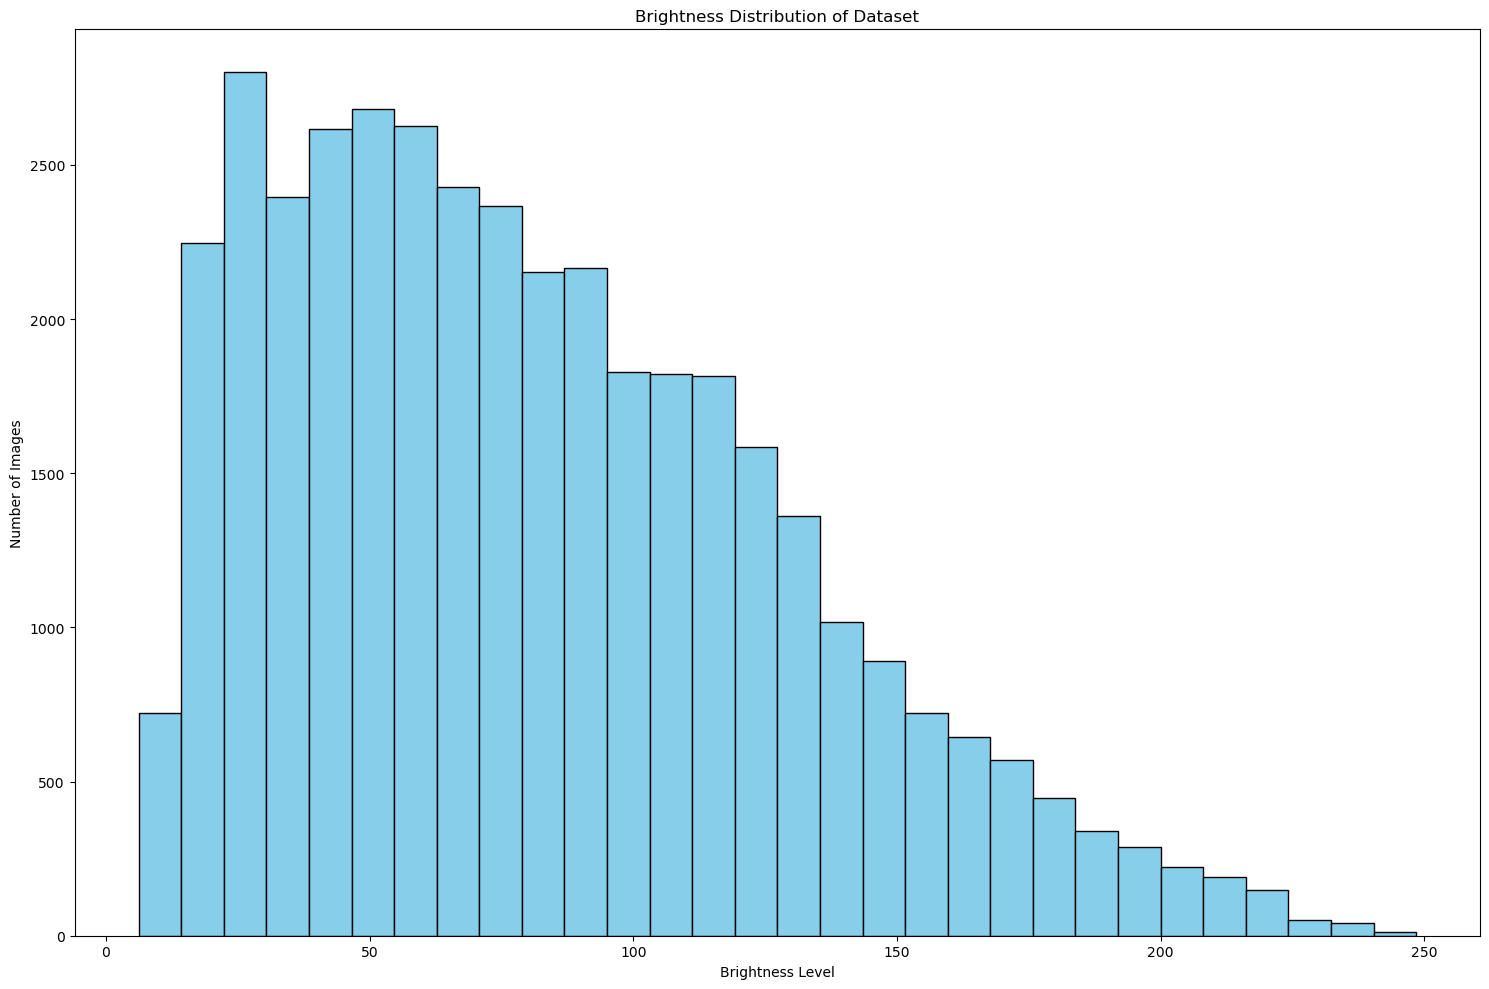

In [10]:
# Initialize list to hold brightness levels
brightness_levels = []

# Function to calculate mean brightness of an image
def calculate_brightness(image_path):
    with Image.open(image_path) as img:
        grayscale_img = img.convert('L')  # Convert to grayscale
        np_image = np.array(grayscale_img)
        return np.mean(np_image)

# Walk through all subfolders and files
for root, dirs, files in os.walk(dataset_dir):
    for filename in files:
        if filename.endswith(('.png', '.jpg', '.jpeg')):  # Add more extensions if needed
            file_path = os.path.join(root, filename)
            try:
                brightness = calculate_brightness(file_path)
                brightness_levels.append(brightness)
            except Exception as e:
                print(f"Error processing {file_path}: {e}")

# Bin brightness levels for histogram
num_bins = 30  # Number of bins for the histogram
plt.hist(brightness_levels, bins=num_bins, color='skyblue', edgecolor='black')

# Set labels and title
plt.xlabel('Brightness Level')
plt.ylabel('Number of Images')
plt.title('Brightness Distribution of Dataset')
plt.tight_layout()
plt.show()

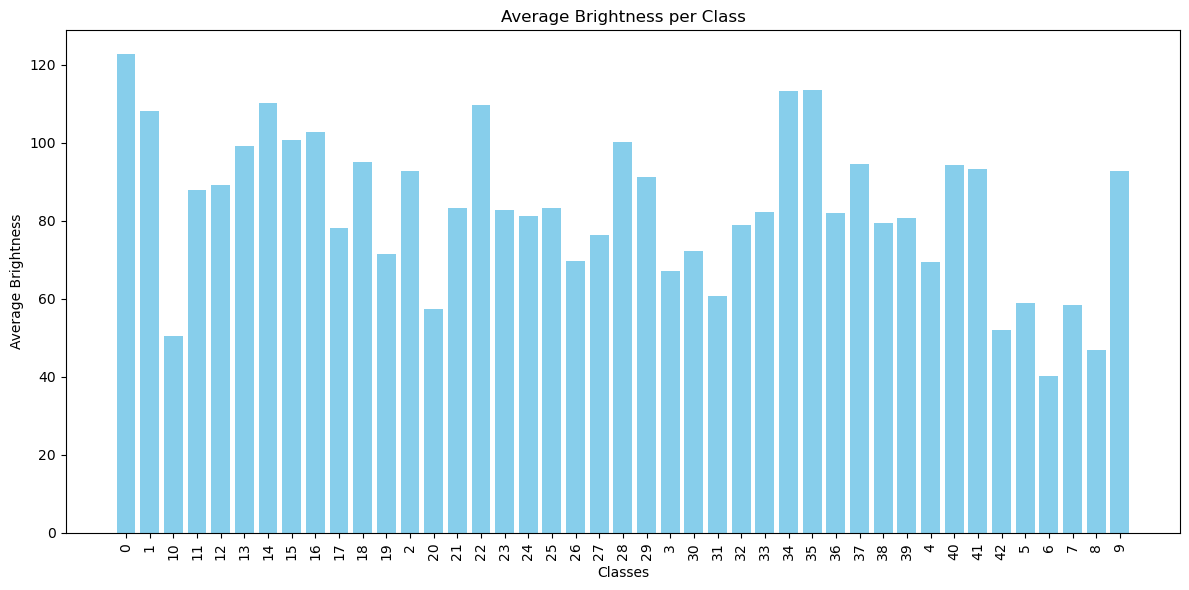

In [13]:

from collections import defaultdict

# Dictionary to store brightness per class
class_brightness = defaultdict(list)

# Collect brightness values per class
for root, dirs, files in os.walk(dataset_dir):
    class_name = os.path.basename(root)
    for filename in files:
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            file_path = os.path.join(root, filename)
            try:
                with Image.open(file_path) as img:
                    grayscale_img = img.convert('L')
                    mean_brightness = np.mean(np.array(grayscale_img))
                    class_brightness[class_name].append(mean_brightness)
            except Exception as e:
                print(f"Error processing {file_path}: {e}")

# Calculate average brightness per class
avg_brightness_per_class = {cls: np.mean(vals) for cls, vals in class_brightness.items()}

# Plot histogram of average brightness per class
classes = list(avg_brightness_per_class.keys())
brightness_values = list(avg_brightness_per_class.values())

plt.figure(figsize=(12, 6))
plt.bar(classes, brightness_values, color='skyblue')
plt.xlabel('Classes')
plt.ylabel('Average Brightness')
plt.title('Average Brightness per Class')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
